In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ensure necessary folders exist
os.makedirs('data', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)

In [3]:
# Generate a realistic 365-day COVID-19 & Healthcare dataset
np.random.seed(101)
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')

In [4]:
# Simulate infection waves, recoveries, and hospitalizations
base_cases = 500 + 300 * np.sin(np.linspace(0, 4 * np.pi, 365))
daily_cases = np.clip(np.round(base_cases + np.random.normal(0, 50, 365)), 50, 2000).astype(int)
daily_recoveries = np.clip(np.round(daily_cases * np.random.uniform(0.85, 0.96, 365)), 30, 2000).astype(int)
hospitalized = np.clip(np.round(daily_cases * np.random.uniform(0.05, 0.15, 365)), 5, 500).astype(int)

In [5]:
# Create DataFrame and save as CSV
df_health = pd.DataFrame({
    'Date': dates,
    'Daily_Cases': daily_cases,
    'Daily_Recoveries': daily_recoveries,
    'Hospitalized': hospitalized
})

df_health['Recovery_Rate_Pct'] = np.round((df_health['Daily_Recoveries'] / df_health['Daily_Cases']) * 100, 1)

df_health.to_csv('data/covid_trends.csv', index=False)
print("covid_trends.csv successfully created in data/ folder!")

covid_trends.csv successfully created in data/ folder!


In [6]:
# Display basic dataset information
print("\nDataset Shape:", df_health.shape)
display(df_health.head())


Dataset Shape: (365, 5)


,Date,Daily_Cases,Daily_Recoveries,Hospitalized,Recovery_Rate_Pct
0,2025-01-01,635,594,56,93.5
1,2025-01-02,542,515,56,95.0
2,2025-01-03,566,486,61,85.9
3,2025-01-04,556,495,61,89.0
4,2025-01-05,574,509,84,88.7


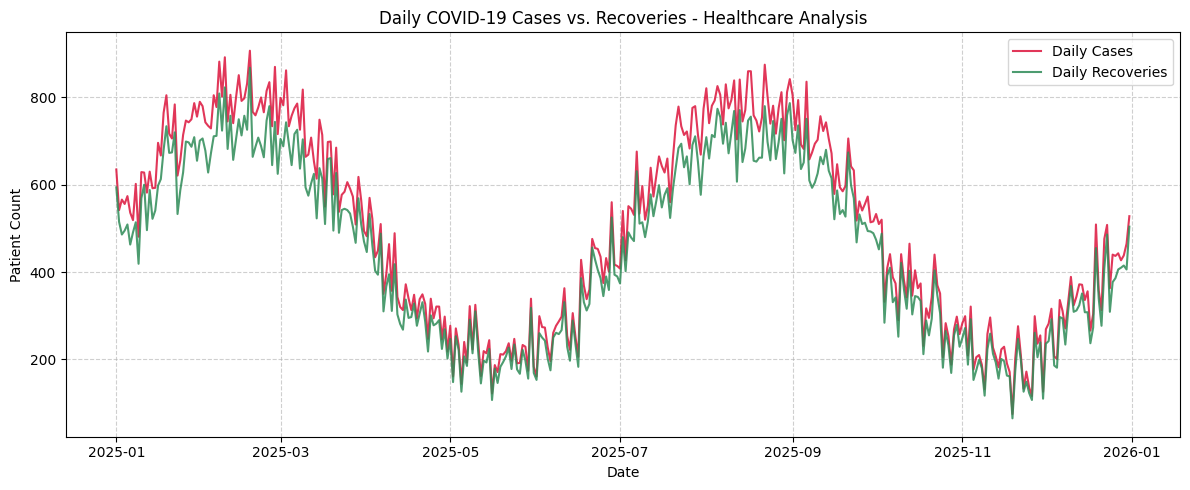

In [7]:
# 1. Daily COVID-19 Cases vs. Recoveries Over Time
plt.figure(figsize=(12, 5))
plt.plot(df_health['Date'], df_health['Daily_Cases'], color='crimson', linewidth=1.5, label='Daily Cases', alpha=0.85)
plt.plot(df_health['Date'], df_health['Daily_Recoveries'], color='seagreen', linewidth=1.5, label='Daily Recoveries', alpha=0.85)
plt.title('Daily COVID-19 Cases vs. Recoveries - Healthcare Analysis')
plt.xlabel('Date')
plt.ylabel('Patient Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

In [8]:
# Save visualization
plt.savefig('visualizations/project4_cases_vs_recoveries.png')
plt.show()

<Figure size 640x480 with 0 Axes>

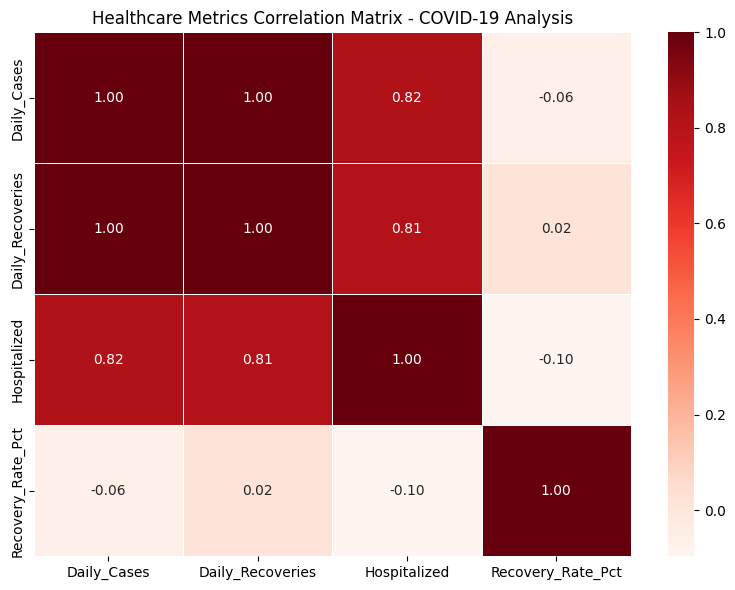

In [9]:
# 2. Correlation Heatmap for Healthcare Metrics
plt.figure(figsize=(8, 6))

# Select numerical healthcare metrics
health_cols = ['Daily_Cases', 'Daily_Recoveries', 'Hospitalized', 'Recovery_Rate_Pct']
corr_matrix = df_health[health_cols].corr()

# Draw heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f", linewidths=0.5)
plt.title('Healthcare Metrics Correlation Matrix - COVID-19 Analysis')
plt.tight_layout()

In [10]:
# Save visualization
plt.savefig('visualizations/project4_correlation_heatmap.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [11]:
# Extract month name for seasonal grouping
df_health['Month'] = df_health['Date'].dt.strftime('%b')

In [12]:
# Order months chronologically
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_hosp = df_health.groupby('Month')['Hospitalized'].mean().reindex(months_order)

C:\Users\ajasl\AppData\Local\Temp\ipykernel_7956\3088528081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_hosp.index, y=monthly_hosp.values, palette='Reds_r')


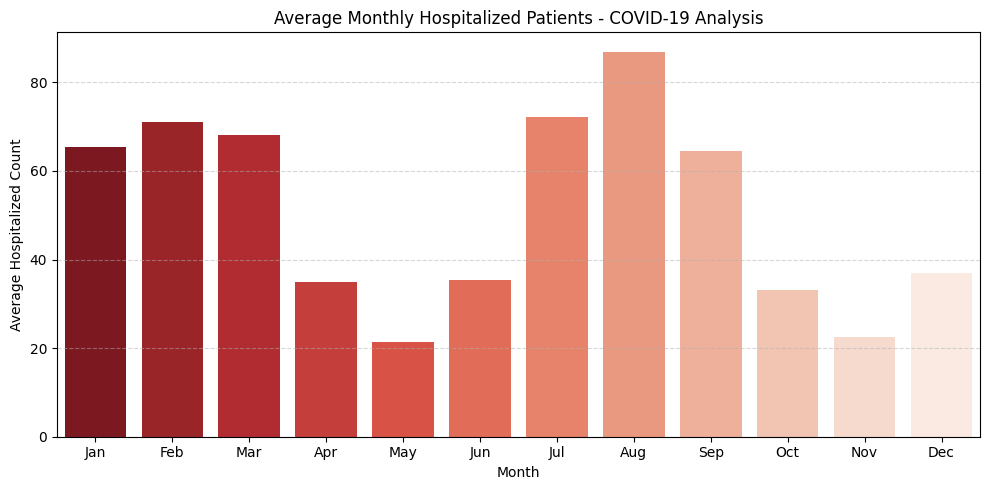

In [13]:
# 3. Monthly Average Hospitalized Patients Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_hosp.index, y=monthly_hosp.values, palette='Reds_r')
plt.title('Average Monthly Hospitalized Patients - COVID-19 Analysis')
plt.xlabel('Month')
plt.ylabel('Average Hospitalized Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

In [14]:
# Save visualization
plt.savefig('visualizations/project4_monthly_hospitalized.png')
plt.show()

<Figure size 640x480 with 0 Axes>